<a href="https://colab.research.google.com/github/dercodeKoenig/test/blob/main/bitmex_maker_cryptodqn_gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
!git clone https://github.com/dercodeKoenig/cryptotest

Cloning into 'cryptotest'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 77 (delta 0), reused 1 (delta 0), pack-reused 74
Unpacking objects: 100% (77/77), done.
Checking out files: 100% (36/36), done.


In [3]:
!mv cryptotest/candles/ .
!ls

candles  cryptotest  drive  sample_data


In [4]:
%cd candles
import os
files = os.listdir(".")
for i in files:
  os.system("unzip "+i)
  os.system("rm "+i)
!ls
%cd ..

/content/candles
candles_object_ADAUSDT.csv   candles_object_LTCUSDT.csv
candles_object_ALGOUSDT.csv  candles_object_MANAUSDT.csv
candles_object_ATOMUSDT.csv  candles_object_MATICUSDT.csv
candles_object_BTCUSDT.csv   candles_object_SHIBUSDT.csv
candles_object_DOTUSDT.csv   candles_object_SOLUSDT.csv
candles_object_ETHUSDT.csv   candles_object_TRXUSDT.csv
/content


In [5]:
!nvidia-smi

NVIDIA-SMI has failed because it couldn't communicate with the NVIDIA driver. Make sure that the latest NVIDIA driver is installed and running.



In [6]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"]="-1"
!pip install ta
import numpy as np
import tensorflow as tf
import time
import pandas as pd
import ta
from tqdm import tqdm
import random
import pickle
from collections import deque
import time
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

  Created wheel for ta: filename=ta-0.10.1-py3-none-any.whl size=28985 sha256=acad8776865f2f71eb71219baf14979d575417f890b2d64b141b601a690337ca
  Stored in directory: /root/.cache/pip/wheels/bc/2a/c2/a56e77d07edc16a1fa7fb012667e55cb0643cfa65996bddecc
Successfully built ta


In [7]:
def sample_to_x(sample):
        
                current_close = sample[-1].c
                current_vol = sample[-1].v

                prev_close = [candle.c for candle in sample]
                prev_high = [candle.h for candle in sample]
                prev_low = [candle.l for candle in sample]

                prev_sma21 = [candle.sma21 for candle in sample]
                prev_sma200 = [candle.sma200 for candle in sample]
                prev_vol = [candle.v for candle in sample]
                vmax = max(prev_vol)
                prev_vol_relative = [prev_vol[o] / vmax for o in range(seq_len)]
                
                
                prev_sma21_relative = [-(current_close - prev_sma21[o]) / prev_sma21[o] for o in range(seq_len)]
                prev_sma200_relative = [-(current_close - prev_sma200[o]) / prev_sma200[o] for o in range(seq_len)]
                prev_close_relative = [-(current_close - prev_close[o]) / prev_close[o] for o in range(seq_len)]
                prev_high_relative = [-(current_close - prev_high[o]) / prev_high[o] for o in range(seq_len)]
                prev_low_relative = [-(current_close - prev_low[o]) / prev_low[o] for o in range(seq_len)]

                
                
                scale = 100 # scale price: 1% -> 1

                prev_sma21_relative_scaled = [i * scale for i in prev_sma21_relative]
                prev_sma200_relative_scaled = [i * scale for i in prev_sma200_relative]

                prev_close_relative_scaled = [i * scale for i in prev_close_relative]
                prev_low_relative_scaled = [i * scale for i in prev_low_relative]
                prev_high_relative_scaled = [i * scale for i in prev_high_relative]
                prev_rsi_14 = [candle.rsi14 for candle in sample]


                x = []
                for o in range(len(prev_close)):
                    ts = []
                    ts.append(prev_close_relative_scaled[o])
                    ts.append(prev_high_relative_scaled[o])
                    ts.append(prev_low_relative_scaled[o])

                    ts.append(prev_sma21_relative_scaled[o])
                    ts.append(prev_sma200_relative_scaled[o])
                    ts.append(prev_vol_relative[o])
                    
                    ts.append(prev_rsi_14[o])

                    x.append(ts)

                x = np.array(x)
                return x
        

In [8]:
def Load(file):
    f = open(file, "rb")
    obj = pickle.load(f)
    f.close()
    return obj

In [9]:
seq_len = int(4*24*2)
comission = -0.01 / 100

class candle_class:
    pass
  
order_value = 1000

class environment():

  def __init__(self):
    pass


  def _next_observation(self):
            candles = self.candles[self.current_step - seq_len + 1:self.current_step + 1]
            
            inference_data = sample_to_x(candles)
            
            return inference_data, np.array([self.position, self.current_win])

  
  def reset(self, first_reset = False):
    self.candles = None
    candles_files = os.listdir("candles")
    use_file = "candles/"+random.choice(candles_files)
    #print(use_file)
    self.candles = Load(use_file)
    
    self.current_step = 200+seq_len if first_reset == False else random.randint(200+seq_len,len(self.candles) - 1000)
    self.position = 0
    self.entry_price = 0
    self.win = 0
    self.current_win = 0
    self.startindex = self.current_step
    self.last_reward = 0


    return self._next_observation()

  
        
        
  def entry(self, price, p):
        self.position += p
        assert self.position == 1 or self.position == 0 or self.position == -1
        if self.position == 0:
          diff = (price - self.entry_price) / self.entry_price * order_value * (self.position-p)
          self.win+=diff
          self.current_win = 0
        else:
          self.entry_price = price
        self.win -= comission * order_value

  def open_order(self, long_short, price):
    self.order = [long_short, price]

  def check_order(self):
    if self.candles[self.current_step].h > self.order[1] and self.order[0] == -1:
      self.entry(self.order[1], -1)
    
    if self.candles[self.current_step].l < self.order[1] and self.order[0] == 1:
      self.entry(self.order[1], 1)

    self.order = [0, 0]

  def step(self, action):
    self.order = [0,0]
    current_close = self.candles[self.current_step].c
    
    if action == 0:
        if self.position != 0:
            self.open_order(-self.position, current_close + self.position * current_close * 0.0005)
    
    if action == 1:
      #short
      if self.position != -1:
        self.open_order(-1, current_close + current_close * 0.0005)

        
    if action == 2:
      #long
      if self.position != 1:
        self.open_order(1, current_close - current_close * 0.0005)
      
        
    self.current_step += 1
    self.check_order()

    if self.position != 0:
      current_price = self.candles[self.current_step].c
      entry = self.entry_price
      diff = (current_price - entry) / entry * order_value

      if self.position == 1:
        self.current_win = diff
      if self.position == -1:
        self.current_win = -diff

    reward_raw = self.win + self.current_win
    reward = reward_raw - self.last_reward
    self.last_reward = reward_raw
    
    done = self.current_step == len(self.candles) -1    
    obs = self._next_observation()

    reward = max(min(reward, 20), -20)
    return obs, reward, done

In [10]:
class DQNAgent:
    def __init__(self, model,
                 n_actions,
                 memory_size = 10000, 
                 optimizer = tf.keras.optimizers.Adam(0.0005), 
                 gamma = 0.99,
                 batch_size =32,
                 name = "dqn1",
                 target_model_sync = 1000,
                 exploration=0.01
                ):
        self.exploration = exploration
        self.gamma = gamma
        self.n_actions = n_actions
        self.batch_size = batch_size
        self.model = model
        self.name = name
        self.memory_size = memory_size
        self.optimizer = optimizer
        self.optimizer = mixed_precision.LossScaleOptimizer(self.optimizer)
        self.m1 = np.eye(self.n_actions, dtype="float32")
        self.target_model = tf.keras.models.clone_model(self.model)
        self.target_model_sync = target_model_sync
   
        self.memory = deque(maxlen = self.memory_size)
      
    
    
    def copy_weights(self):
        self.target_model.set_weights(self.model.get_weights())
      
    def load_weights(self):
        self.model.load_weights(self.name)
    def save_weights(self):
        self.model.save_weights(self.name, overwrite = True)
        
    @tf.function(jit_compile = True)
    def model_call(self, x):
        return tf.math.argmax(self.model(x), axis = 1)
    
    def select_actions(self, current_states, positions):
        
        if random.random() < self.exploration:
            num_inputs = len(positions)
            return tf.random.uniform(shape=[num_inputs], minval=0, maxval=3, dtype=tf.int32)
        
        return self.model_call([current_states, positions]).numpy()
        
    def observe_sasrt(self, state, action, next_state, reward, terminal):
        self.memory.append([state, action, reward, 1-int(terminal), next_state])
        
    @tf.function(jit_compile = True)
    def get_target_q(self, next_states, rewards, terminals):
        estimated_q_values_next = self.target_model(next_states)
        q_batch = tf.math.reduce_max(estimated_q_values_next, axis=1)
        target_q_values = q_batch * self.gamma * terminals + rewards
        return target_q_values
    
        
    @tf.function(jit_compile = False)
    def tstep(self, states, next_states, rewards, terminals, masks):
        target_q_values = self.get_target_q(next_states, rewards, terminals)
        
        with tf.GradientTape() as t:
            estimated_q_values = tf.math.reduce_sum(self.model(states, training=True) * masks, axis=1)
            loss = tf.keras.losses.mean_absolute_error(target_q_values, estimated_q_values)
            scaled_loss = self.optimizer.get_scaled_loss(loss)
        
        scaled_gradients = t.gradient(scaled_loss, self.model.trainable_variables)
        gradient = self.optimizer.get_unscaled_gradients(scaled_gradients)
        self.optimizer.apply_gradients(zip(gradient, self.model.trainable_variables))
        
        return loss, tf.reduce_mean(estimated_q_values)
      
    def update_parameters(self):
        sarts_batch = random.sample(self.memory, self.batch_size)
        
        states = [x[0] for x in sarts_batch]
        states_1 = np.array([x[0] for x in states], dtype="float32")
        states_2 = np.array([x[1] for x in states], dtype="float32")
        
        actions = [x[1] for x in sarts_batch]
        rewards = np.array([x[2] for x in sarts_batch], dtype="float32")
        terminals = np.array([x[3] for x in sarts_batch], dtype="float32")
        
        next_states = [x[4] for x in sarts_batch]
        next_states_1 = np.array([x[0] for x in next_states], dtype="float32")
        next_states_2 = np.array([x[1] for x in next_states], dtype="float32")
        
        masks = self.m1[actions]
        
        self.total_steps_trained+=1
        if self.total_steps_trained % self.target_model_sync == 0:
            self.copy_weights()
        
        return self.tstep([states_1, states_2], [next_states_1, next_states_2], rewards, terminals, masks)
    
    def train(self, num_steps, envs, log_interval = 1000, warmup = 0, train_steps_per_step = 1):
        self.total_steps_trained = -1

        num_envs = len(envs)
        states = [x.reset(True) for x in envs]
        
        current_episode_reward_sum = 0
        times= deque(maxlen=10)
        start_time = time.time()
        
        self.longs = 0
        self.shorts = 0

        self.total_rewards = []
        self.losses = [0]
        self.q_v = [0]
        
        def save_current_run():
            self.save_weights()
            file = open("drive/MyDrive/logs/loss_log.txt", "a")  
            for loss in self.losses:
                        file.write(str(loss))
                        file.write("\n")
            file.close()

            file = open("drive/MyDrive/logs/qv_log.txt", "a")  
            for qv in self.q_v:
                        file.write(str(qv))
                        file.write("\n")
            file.close()

            file = open("drive/MyDrive/logs/rewards_log.txt", "a")  
            for total_reward in self.total_rewards:
                        file.write(str(total_reward))
                        file.write("\n")
            file.close()
            
    

            self.total_rewards = []
            self.losses = [0]
            self.q_v = [0]
        
        try:
            for i in range(num_steps):
                if i % log_interval == 0:
                    progbar = tf.keras.utils.Progbar(log_interval, interval=0.05, stateful_metrics = ["reward sum", "t", "l/s"])
                    self.longs = 0
                    self.shorts = 0


                states_1 = np.array([x[0] for x in states])
                states_2 = np.array([x[1] for x in states])
                actions = self.select_actions(states_1, states_2)
                for action in actions:
                    if action == 1:
                        self.shorts+=1
                    elif action == 2:
                        self.longs+=1

                sasrt_pairs = []
                for index in range(num_envs):
                    sasrt_pairs.append([states[index], actions[index]]+[x for x in envs[index].step(actions[index])])

                next_states = [x[2] for x in sasrt_pairs]

                reward = [x[3] for x in sasrt_pairs]
                current_episode_reward_sum += np.sum(reward)

                self.total_rewards.extend(reward)

                for index, o in enumerate(sasrt_pairs):
                    #print(o)
                    if o[4] == True:
                        next_states[index] = envs[index].reset()
                    self.observe_sasrt(o[0], o[1], o[2], o[3], o[4])

                states = next_states
                if i > warmup:
                    for _ in range(train_steps_per_step):
                        loss, q = self.update_parameters()
                        self.losses.append(loss.numpy())
                        self.q_v.append(q.numpy())
                else:
                    loss, q = 0, 0

                end_time = time.time()
                elapsed = (end_time - start_time) * 1000
                times.append(elapsed)
                start_time = end_time


                if (i+1) % log_interval == 0:
                    save_current_run()

                progbar.update(i%log_interval+1, values = 
                               [("loss", np.mean(self.losses[-train_steps_per_step:])),
                                ("mean q", np.mean(self.q_v[-train_steps_per_step:])),
                                ("rewards", np.mean(reward)),
                                ("reward sum", current_episode_reward_sum),
                                ("l/s", (self.longs - self.shorts) / (1+self.longs+self.shorts)),
                                ("t", np.mean(times))])
        
        except KeyboardInterrupt:
            print("\n\nbreak!")
        
        save_current_run()
            


In [11]:
tf.keras.backend.clear_session()

mixed_precision.set_global_policy('mixed_float16')

if True:
  inputs_1 = tf.keras.layers.Input(shape = (seq_len, 7))
  inputs_pos = tf.keras.layers.Input(shape = (2))

  x = tf.keras.layers.Reshape((seq_len,7))(inputs_1)

  x2 = tf.keras.layers.Conv1D(128,9, padding="same")(x)
  x2 = tf.keras.layers.LeakyReLU(alpha=0.1)(x2)
  x2 = tf.keras.layers.Dense(64)(x2)
  x2 = tf.keras.layers.LeakyReLU(alpha=0.1)(x2)

  x3 = tf.keras.layers.Conv1D(128,5, padding="same")(x2)
  x3 = tf.keras.layers.LeakyReLU(alpha=0.1)(x3)
  x3 = tf.keras.layers.Dense(64)(x3)
  x3 = tf.keras.layers.LeakyReLU(alpha=0.1)(x3)

  x2 = tf.keras.layers.Add()([x2,x3])

  x = tf.keras.layers.Concatenate()([x,x2])

  x = tf.keras.layers.Dense(128)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

  x2 = tf.keras.layers.Conv1D(128,5, padding="same")(x)
  x2 = tf.keras.layers.LeakyReLU(alpha=0.1)(x2)
  x = tf.keras.layers.Add()([x,x2])

  x = tf.keras.layers.Dense(128)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

  x = tf.keras.layers.LSTM(128)(x)

  #xe = tf.keras.layers.Lambda(lambda x: x[:,-1])(x)
  #xe = tf.keras.layers.Reshape((1,xe.shape[1]))(xe)
  #x = tf.keras.layers.MultiHeadAttention(8, x.shape[2])(xe, x)
  #x = tf.keras.layers.Add()([x, xe])
  #x = tf.keras.layers.Flatten()(x)

  x = tf.keras.layers.Concatenate()([inputs_pos, x])

  x = tf.keras.layers.Dense(256)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

  x = tf.keras.layers.Dense(512)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)

  x = tf.keras.layers.Dense(256)(x)
  x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
          
  outputs = tf.keras.layers.Dense(3, activation = "linear", use_bias=False, dtype="float32")(x)
  model = tf.keras.Model([inputs_1,inputs_pos], outputs)
model.summary()

The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 192, 7)]     0           []                               
                                                                                                  
 reshape (Reshape)              (None, 192, 7)       0           ['input_1[0][0]']                
                                                                                                  
 conv1d (Conv1D)                (None, 192, 128)

In [12]:
opt = tf.keras.optimizers.Adam(0.0001, clipvalue = 1)

agent = DQNAgent(
    model = model, 
    n_actions = 3, 
    memory_size = 400000,
    gamma=0.99,
    optimizer = opt, 
    batch_size = 256, 
    target_model_sync = 100,
    exploration=0.01,
    name="drive/MyDrive/deep_crypto_trading_l4.h5")

In [13]:
agent.load_weights()

In [14]:
num_parallel = 8
envs = [environment() for _ in range(num_parallel)]

In [15]:
n = int(20000)
agent.train(num_steps = n, envs = envs, warmup = n, log_interval = n, train_steps_per_step=1)

 1530/20000 [=>............................] - ETA: 54:06 - loss: 0.0000e+00 - mean q: 0.0000e+00 - rewards: 0.0311 - reward sum: 380.9135 - l/s: -0.0409 - t: 158.8161

break!


In [16]:
len(agent.memory)

12240

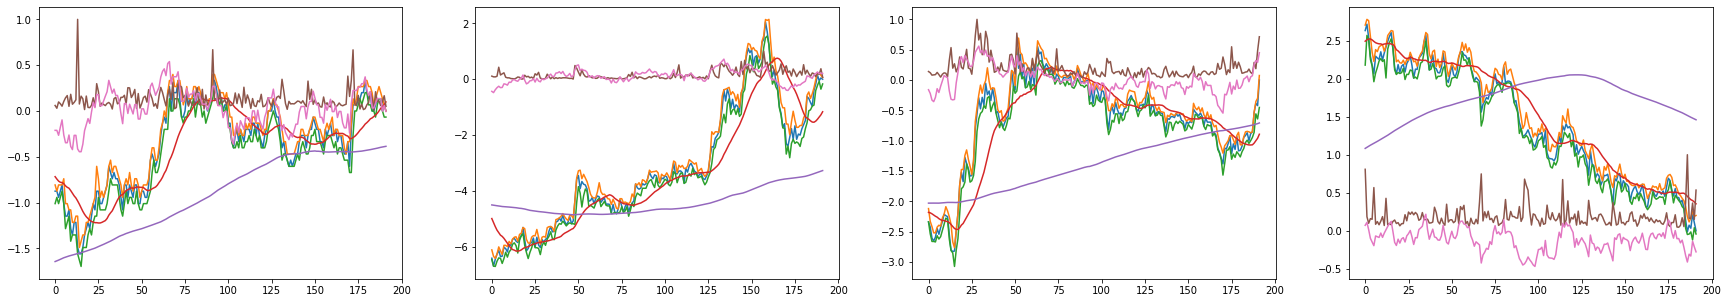

In [17]:
num_parallel = 4
envs = [environment() for _ in range(num_parallel)]

if True:    
    fig, ax = plt.subplots(1,num_parallel,figsize=(30,5))
    for o in range(num_parallel):
        x = envs[o].reset(True)[0]
        x_ = np.transpose(x)
        for i in x_:
            ax[o].plot(i) if num_parallel > 1 else ax.plot(i) 

In [18]:
n = 100000000
agent.train(num_steps = n, envs = envs, warmup = 0, log_interval = 1000, train_steps_per_step=1)

  64/1000 [>.............................] - ETA: 4:09:43 - loss: 0.7921 - mean q: 5.6090 - rewards: 0.0084 - reward sum: 2.1490 - l/s: -0.1281 - t: 15869.7882  

break!


In [19]:
nx = [0,0,0]
for i in agent.memory:
    nx[i[1]]+=1
    
nx

[2680, 5120, 4700]

In [20]:
agent.save_weights()

In [21]:
m = agent.memory

In [22]:
#agent.memory = deque(maxlen = 1000000)
for i in m:
    agent.memory.append(i)
#del m
len(agent.memory)

RuntimeError: ignored